# 후방 전개·회수·포획

문 개방부터 줄 전개, 견인, 회수, 출구 접촉과 포획까지 저장된 실제 시뮬레이션을 확인합니다. 시간 절약을 위해 기본값은 저장 결과를 읽으며 재계산 옵션을 제공합니다.

## 실행 준비

프로젝트 전용 환경에서 실행합니다. 먼저 README의 `build-aero` 명령으로 실제 AVL 데이터를 생성해야 합니다. 예시 입력은 팀 기체의 설계값이 아닙니다.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dbf_stability import *
from dbf_stability.analysis import load_result
ROOT = Path.cwd() if (Path.cwd() / "examples").exists() else Path.cwd().parent
c = load_case(ROOT / "examples/reference.yaml")
aero = AeroDatabase(ROOT / "outputs/aero_database.npz")
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.2})
pd.set_option("display.max_columns", 12)
print("Actual solver:", aero.metadata["solver"])
print("Raw solver files:", aero.metadata["raw_directory"])


Actual solver: AVL 3.52
Raw solver files: D:\DBF\안정성 툴\outputs\avl_runs_5f9062ee


## 입력과 재계산 선택

`RUN_FULL = True`로 바꾸면 전 과정을 다시 계산합니다. 기본값은 입력·출력·원시 상태가 함께 보존된 결과를 읽습니다. 조종 입력은 공개한 시간 이력이며 자동조종이 아닙니다.

In [2]:
RUN_FULL = False
mission_config = changed(load_case(ROOT / 'examples/mission_scheduled.yaml'), **{'cable.segments':40})
if RUN_FULL:
    mission = simulate(mission_config, aero, phase='mission', output=ROOT/'outputs/mission_40')
else:
    mission = load_result(ROOT/'outputs/mission_40')
print('Case:', mission.config['name'])
print('Applied control histories:', mission.config['flight']['controls'])
pd.Series({k:mission.summary[k] for k in ['status','duration_s','capture_status','max_tension_N','max_contact_N','max_capture_N','max_pitch_change_deg','physical_validation']})

Case: research_reference_not_team_aircraft
Applied control histories: {'elevator_delta_deg': [[0, 0], [0.6, 0], [2, -0.7890757953563572], [5, -0.7890757953563572], [9.7, 0], [11, 0]], 'thrust_delta_N': [[0, 0], [0.6, 0], [2, 0.7151789879701331], [5, 0.7151789879701331], [9.7, 0], [11, 0]]}


status                                    completed
duration_s                                     11.0
capture_status                             captured
max_tension_N                               8.13182
max_contact_N                              4.667797
max_capture_N                              5.735788
max_pitch_change_deg                      18.638615
physical_validation     unvalidated_assumption_case
dtype: object

## 분할 수에 따른 포획 결과

40구간에서는 포획했지만 10·20구간에서는 포획하지 못했습니다. 아래 재생은 40구간 결과이며, 이 차이가 남아 있으므로 수렴한 예측으로 취급하지 않습니다.

In [3]:
mesh = pd.read_csv(ROOT/'outputs/mission_convergence/sweep.csv')
mesh[['cable.segments','capture_status','max_tension_N','contact_impulse_Ns','max_capture_N']]

,cable.segments,capture_status,max_tension_N,contact_impulse_Ns,max_capture_N
0,10,not_captured,12.017877,1.493513,0.000000
1,20,not_captured,7.560130,2.061911,0.000000
2,40,captured,8.131820,1.523277,5.735788
3,40,captured,8.131820,1.523277,5.735788


## 전 과정 이력

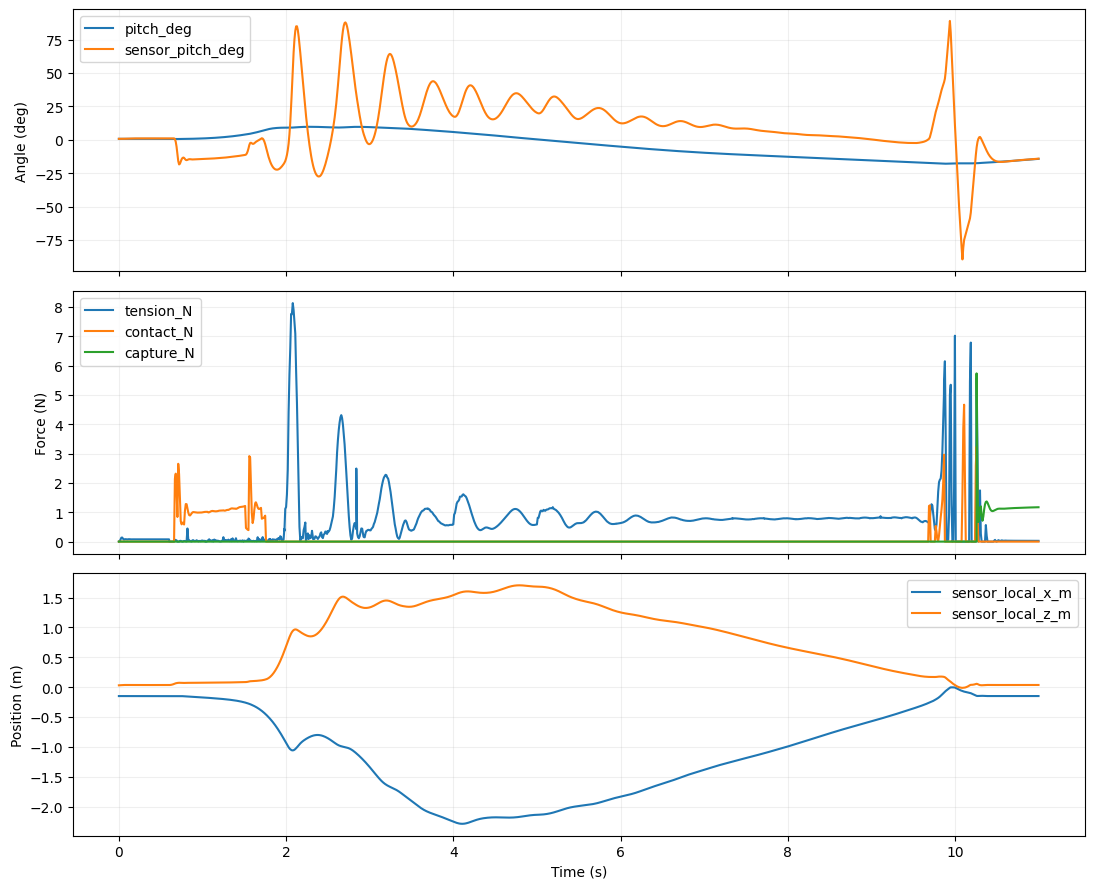

In [4]:
fig, axes = plt.subplots(3,1,figsize=(11,9),sharex=True)
for key in ['pitch_deg','sensor_pitch_deg']:
    axes[0].plot(mission.time,mission.table[key],label=key)
for key in ['tension_N','contact_N','capture_N']:
    axes[1].plot(mission.time,mission.table[key],label=key)
for key in ['sensor_local_x_m','sensor_local_z_m']:
    axes[2].plot(mission.time,mission.table[key],label=key)
for ax,label in zip(axes,['Angle (deg)','Force (N)','Position (m)']):
    ax.set_ylabel(label); ax.legend()
axes[2].set_xlabel('Time (s)');fig.tight_layout();plt.show()

## 사건과 한계 초과

In [5]:
display(pd.DataFrame(mission.events))
print('Limit violations:', mission.summary['violations'])
print('Convergence established:', mission.summary['numerically_converged'])

,time_s,event,method
0,0.01000,stowed,NaN
1,0.60000,internal,NaN
2,1.68000,payout,NaN
3,4.01000,tow,NaN
4,5.01000,recovery,NaN
5,9.50000,internal,NaN
6,10.25898,capture_engaged,compliant latch; velocities continuous
7,10.26000,captured,NaN


Limit violations: []
Convergence established: False


## 3차원 재생

In [6]:
from dbf_stability.plots import export_plots
export_plots(mission, ROOT/'outputs/mission_40')
print('Open:', ROOT/'outputs/mission_40/replay.html')

Open: D:\DBF\안정성 툴\outputs\mission_40\replay.html


## 판독

포획 구속 작동 여부와 임무의 적합성은 별개입니다. 자세 변화·고도·장력·접촉 침투량·한계 초과를 함께 확인해야 합니다. 접촉 물성이 가정값이므로 최대 충격력을 실물 강도 판정에 바로 사용하지 마세요. 저장 결과의 `inputs.json`이 해당 실행에 사용된 입력입니다.